# Assignment 6 - Model Evaluation, Explainability, and Fairness Reflection

- **Course:** MBAI 5310G: AI Programming - Ontario Tech University
- **Dataset:** Digital Subscription Retention Dataset (`digital_subscription_retention_dataset.csv`)
- **Model:** Decision Tree Classifier (scikit-learn)

This notebook trains a Decision Tree classifier to predict customer churn for a digital subscription business, then evaluates the model, explains its predictions with feature importance, SHAP, and LIME, analyzes its errors, and reflects on fairness across customer groups. 

## Task 1: Load and Understand the Dataset

We load the dataset and inspect its structure before any modeling. We check the dataset size, column names, data types, missing values, duplicate records, and the distribution of the target variable. The target variable is `churn`, which shows whether a customer left the service (1) or stayed (0).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("digital_subscription_retention_dataset.csv")

# Display the first five rows
df.head()

,customer_id,age,age_group,gender,region,income,tenure_months,monthly_spend,website_visits,support_tickets,satisfaction_score,contract_type,payment_method,marketing_emails_opened,days_since_last_purchase,discount_used,membership_level,primary_device,complained_last_month,churn
0,DS0001,37,36-50,Female,North,65196.0,14,49.17,27,0.0,4.0,Month-to-month,Credit Card,9,119,No,Silver,Mobile,No,0
1,DS0002,60,51+,Male,South,70625.0,20,94.85,24,0.0,10.0,Two-year,Bank Transfer,12,113,Yes,Platinum,Mobile,No,0
2,DS0003,47,36-50,Female,North,55259.0,30,111.68,6,1.0,1.0,Month-to-month,PayPal,2,68,Yes,Platinum,Desktop,No,1
3,DS0004,38,36-50,Female,West,55971.0,72,102.88,3,0.0,9.0,Month-to-month,Credit Card,4,155,No,Gold,Mobile,No,0
4,DS0005,34,26-35,Female,East,59449.0,69,93.29,25,1.0,9.0,Two-year,Credit Card,7,76,Yes,Silver,Desktop,No,1


**Dataset size (rows and columns).**

In [2]:
df.shape

(385, 20)

**Column names.**

In [8]:
df.columns

Index(['customer_id', 'age', 'age_group', 'gender', 'region', 'income',
       'tenure_months', 'monthly_spend', 'website_visits', 'support_tickets',
       'satisfaction_score', 'contract_type', 'payment_method',
       'marketing_emails_opened', 'days_since_last_purchase', 'discount_used',
       'membership_level', 'primary_device', 'complained_last_month', 'churn'],
      dtype='object')

**Data types and non-null counts.**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               385 non-null    object 
 1   age                       385 non-null    int64  
 2   age_group                 385 non-null    object 
 3   gender                    385 non-null    object 
 4   region                    385 non-null    object 
 5   income                    373 non-null    float64
 6   tenure_months             385 non-null    int64  
 7   monthly_spend             375 non-null    float64
 8   website_visits            385 non-null    int64  
 9   support_tickets           380 non-null    float64
 10  satisfaction_score        376 non-null    float64
 11  contract_type             385 non-null    object 
 12  payment_method            377 non-null    object 
 13  marketing_emails_opened   385 non-null    int64  
 14  days_since

**Missing values per column.**

In [5]:
df.isnull().sum()

customer_id                  0
age                          0
age_group                    0
gender                       0
region                       0
income                      12
tenure_months                0
monthly_spend               10
website_visits               0
support_tickets              5
satisfaction_score           9
contract_type                0
payment_method               8
marketing_emails_opened      0
days_since_last_purchase     0
discount_used                0
membership_level             7
primary_device               6
complained_last_month        0
churn                        0
dtype: int64

**Duplicate records.**

In [6]:
df.duplicated().sum()

np.int64(5)

**Target variable distribution.**

In [9]:
# Count of each churn class
df["churn"].value_counts()

churn
0    254
1    131
Name: count, dtype: int64

In [10]:
# Target distribution as a percentage
df["churn"].value_counts(normalize=True) * 100

churn
0    65.974026
1    34.025974
Name: proportion, dtype: float64

### Explanation of the Dataset and Target Variable

- **Dataset:** The data describes customers of a digital subscription service. It has 385 records and 20 columns covering demographics (age, age group, gender, region, income), subscription behaviour (tenure, monthly spend, contract type, payment method, membership level), engagement (website visits, marketing emails opened, days since last purchase, primary device), and service signals (support tickets, satisfaction score, complaint in the last month).
- **Target variable:** `churn`. A value of 1 means the customer left the service and 0 means the customer stayed.
- **Balance:** The target is **imbalanced**. About 66% of customers did not churn (254 records) and about 34% did churn (131 records). This matters because a model could reach roughly 66% accuracy simply by predicting that everyone stays, so accuracy alone is not a reliable measure for this problem.
- **Data quality:** The dataset contains 5 duplicate records and small numbers of missing values across several columns (income, monthly spend, support tickets, satisfaction score, payment method, membership level, primary device). These are handled in Task 3.

## Task 2: Define Features and Target Variable

We separate the target variable from the input features. We remove the identifier column and keep the group columns aside for fairness analysis only, so they are not used as model input.

In [11]:
# Remove duplicate records first so the model does not learn from repeated rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (380, 20)


In [12]:
# Define the target variable
y = df["churn"]

# Keep the group / sensitive columns aside for later fairness analysis
fairness_columns = df[["gender", "age_group", "region"]]

# Define the input features
# Remove customer_id (identifier), churn (target), and the group columns
X = df.drop(columns=["customer_id", "churn", "gender", "age_group", "region"])

# Display the input features
X.head()

,age,income,tenure_months,monthly_spend,website_visits,support_tickets,satisfaction_score,contract_type,payment_method,marketing_emails_opened,days_since_last_purchase,discount_used,membership_level,primary_device,complained_last_month
0,37,65196.0,14,49.17,27,0.0,4.0,Month-to-month,Credit Card,9,119,No,Silver,Mobile,No
1,60,70625.0,20,94.85,24,0.0,10.0,Two-year,Bank Transfer,12,113,Yes,Platinum,Mobile,No
2,47,55259.0,30,111.68,6,1.0,1.0,Month-to-month,PayPal,2,68,Yes,Platinum,Desktop,No
3,38,55971.0,72,102.88,3,0.0,9.0,Month-to-month,Credit Card,4,155,No,Gold,Mobile,No
4,34,59449.0,69,93.29,25,1.0,9.0,Two-year,Credit Card,7,76,Yes,Silver,Desktop,No


### Explanation of the Feature and Target Choice

- **Target variable:** `churn` (1 = left, 0 = stayed). This is what the model tries to predict.
- **Input features:** all remaining behavioural and profile columns, such as age, income, tenure_months, monthly_spend, website_visits, support_tickets, satisfaction_score, contract_type, payment_method, marketing_emails_opened, days_since_last_purchase, discount_used, membership_level, primary_device, and complained_last_month.
- **Removed from model input:** `customer_id`, because it is only an identifier and carries no predictive meaning.
- **Kept only for fairness reflection:** `gender`, `age_group`, and `region`. These group columns are not used as model inputs. Using sensitive group columns directly as features can lead the model to make decisions based on the group itself, so we hold them aside and use them only in Task 14 to check whether the model behaves fairly across groups.

## Task 3: Data Preprocessing

Machine learning models work with numerical data and cannot train on missing values or text categories. We prepare the data by filling missing values, converting categorical columns into numbers, and producing the final feature set.

In [13]:
# Identify numerical and categorical feature columns
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'income', 'tenure_months', 'monthly_spend', 'website_visits', 'support_tickets', 'satisfaction_score', 'marketing_emails_opened', 'days_since_last_purchase']
Categorical features: ['contract_type', 'payment_method', 'discount_used', 'membership_level', 'primary_device', 'complained_last_month']


**Handle missing values.** Numerical columns are filled with the column median (robust to outliers). Categorical columns are filled with the most frequent value (the mode).

In [14]:
# Fill missing numerical values with the median
for col in numerical_features:
    X[col] = X[col].fillna(X[col].median())

# Fill missing categorical values with the mode
for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])

# Confirm there are no missing values left
print("Missing values remaining:", int(X.isnull().sum().sum()))

Missing values remaining: 0


**Convert categorical variables into numerical format** using one-hot encoding.

In [15]:
# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

# Display the final feature set
print("Final feature set shape:", X.shape)
X.head()

Final feature set shape: (380, 21)


,age,income,tenure_months,monthly_spend,website_visits,support_tickets,satisfaction_score,marketing_emails_opened,days_since_last_purchase,contract_type_One-year,...,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,discount_used_Yes,membership_level_Gold,membership_level_Platinum,membership_level_Silver,primary_device_Mobile,primary_device_Tablet,complained_last_month_Yes
0,37,65196.0,14,49.17,27,0.0,4.0,9,119,False,...,True,False,False,False,False,False,True,True,False,False
1,60,70625.0,20,94.85,24,0.0,10.0,12,113,False,...,False,False,False,True,False,True,False,True,False,False
2,47,55259.0,30,111.68,6,1.0,1.0,2,68,False,...,False,False,True,True,False,True,False,False,False,False
3,38,55971.0,72,102.88,3,0.0,9.0,4,155,False,...,True,False,False,False,True,False,False,True,False,False
4,34,59449.0,69,93.29,25,1.0,9.0,7,76,False,...,True,False,False,True,False,False,True,False,False,False


### Why Preprocessing Is Necessary

- **Missing values:** a Decision Tree cannot train on empty cells, so each gap must be filled. Median and mode imputation keep all 380 rows instead of dropping customers.
- **Categorical to numerical:** the model only understands numbers, so text categories such as contract type and payment method are converted into 0/1 columns using one-hot encoding. `drop_first=True` avoids redundant columns.
- **Final feature set:** after encoding, the 15 input columns become 21 numerical feature columns that the model can use for training.

## Task 4: Train/Test Split

We divide the data into a training set and a testing set. The training set teaches the model, and the testing set checks how well the model works on customers it has never seen.

In [16]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# We keep the fairness columns aligned with the same split for later analysis
X_train, X_test, y_train, y_test, fairness_train, fairness_test = train_test_split(
    X,
    y,
    fairness_columns,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the size of each set
print("Training set size:", X_train.shape[0], "customers")
print("Testing set size: ", X_test.shape[0], "customers")
print("Number of features:", X_train.shape[1])

Training set size: 304 customers
Testing set size:  76 customers
Number of features: 21


### Explanation of the Train/Test Split

- **Training set:** 304 customers (80%). The model learns the relationship between the features and churn from this data.
- **Testing set:** 76 customers (20%). This data is held back and used only to evaluate the model on new, unseen customers.
- **Why we split the data:** if we evaluated the model on the same data it trained on, the scores would look too good and would not show how the model performs on real new customers. The split gives an honest estimate of real-world performance.
- **Difference between training and testing data:** training data is used to fit the model (it sees the answers), while testing data is used only to measure performance (the model does not learn from it). We use `stratify=y` so both sets keep the same churn balance, and `random_state=42` so the split is reproducible.

## Task 5: Train a Classification Model

We train a simple Decision Tree classifier. A Decision Tree is easy to understand and explain, which suits this assignment. We use `max_depth=4` to keep the tree simple and reduce overfitting.

In [17]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
# Use the trained model to predict churn on the test data
y_pred = model.predict(X_test)

# Compare actual and predicted values for the first 10 test customers
comparison = pd.DataFrame({
    "Actual Churn": y_test.values,
    "Predicted Churn": y_pred
})
comparison.head(10)

,Actual Churn,Predicted Churn
0,0,0
1,0,0
2,1,0
3,1,0
4,0,0
5,0,0
6,1,0
7,0,0
8,0,0
9,1,0


### What the Model Learns and First Predictions

- **What the model is trying to learn:** the patterns in customer behaviour (such as support tickets, satisfaction, tenure, and spending) that separate customers who churn from customers who stay, so it can predict churn for new customers.
- **First predictions:** in the first 10 test rows, most predictions are 0 (Not Churn) and several match the actual value, so they are correct. A few rows where the actual value is 1 but the prediction is 0 are incorrect: these are customers who actually churned but the model expected them to stay. This early view already hints that the model tends to predict Not Churn, which we confirm with proper metrics next.

## Task 6: Evaluate the Model

We evaluate the model using four standard classification metrics: accuracy, precision, recall, and F1-score. Accuracy alone is not enough for an imbalanced problem like churn.

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate the four evaluation metrics on the test data
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Display the metrics in a table
metrics_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})
metrics_results.round(4)

,Metric,Score
0,Accuracy,0.6711
1,Precision,0.6000
2,Recall,0.1154
3,F1-Score,0.1935


### Meaning of Each Metric and the Most Important One

- **Accuracy (≈0.67):** the share of all predictions that were correct. It looks acceptable, but it is inflated by class imbalance: predicting that every customer stays would already score about 0.66, so the model is barely above that baseline.
- **Precision (≈0.60):** of the customers the model predicted would churn, about 60% actually churned. When the model does flag churn, it is reasonably trustworthy.
- **Recall (≈0.12):** of the customers who actually churned, the model caught only about 12%. This is very low and is the model's main weakness.
- **F1-Score (≈0.19):** the balance between precision and recall. It is low because recall is so poor.

**Most important metric for this business:** **Recall.** This is a retention business, so the costly mistake is failing to identify a customer who is about to leave. A model that misses most churners (recall ≈0.12) cannot support retention well, even though its accuracy looks reasonable.

## Task 7: Confusion Matrix

A confusion matrix breaks the predictions into four groups so we can see exactly what kinds of mistakes the model makes. Here 0 means Not Churn and 1 means Churn.

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Build the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract the four values
tn, fp, fn, tp = cm.ravel()

# Show the confusion matrix as a labelled table
cm_table = pd.DataFrame(
    cm,
    index=["Actual Not Churn (0)", "Actual Churn (1)"],
    columns=["Predicted Not Churn (0)", "Predicted Churn (1)"]
)
cm_table

,Predicted Not Churn (0),Predicted Churn (1)
Actual Not Churn (0),48,2
Actual Churn (1),23,3


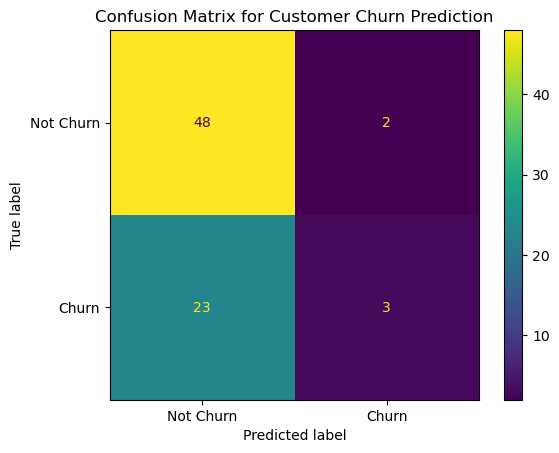

In [21]:
# Visualize the confusion matrix
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
display.plot()
plt.title("Confusion Matrix for Customer Churn Prediction")
plt.show()

In [22]:
# Summary table of the four confusion matrix values
confusion_summary = pd.DataFrame({
    "Type": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Meaning": [
        "Correctly predicted the customer did not churn",
        "Predicted churn, but the customer did not churn",
        "Predicted not churn, but the customer actually churned",
        "Correctly predicted the customer churned"
    ],
    "Value": [tn, fp, fn, tp]
})
confusion_summary

,Type,Meaning,Value
0,True Negative,Correctly predicted the customer did not churn,48
1,False Positive,"Predicted churn, but the customer did not churn",2
2,False Negative,"Predicted not churn, but the customer actually...",23
3,True Positive,Correctly predicted the customer churned,3


### Interpretation and Business Meaning of the Errors

The confusion matrix values are: True Negative = 48, False Positive = 2, False Negative = 23, True Positive = 3.

- **False Positive (2):** the model predicted churn for a customer who actually stayed. Business cost: a small amount of wasted retention spend (an unnecessary discount or outreach).
- **False Negative (23):** the model predicted the customer would stay, but the customer actually churned. Business cost: a real at-risk customer is missed and no retention action is taken, so the company loses recurring revenue.

**Which error is more serious here:** the **False Negatives**. There are 23 of them versus only 2 false positives, and for a subscription business a missed churner (lost revenue) is usually more expensive than a wasted retention offer. The model is far too cautious about predicting churn, which is exactly the wrong trade-off for retention.

## Task 8: Error Analysis

We look more closely at the model's individual mistakes by labelling every test prediction with its error type and counting how often each type occurs.

In [23]:
# Build an error analysis table
error_analysis = pd.DataFrame({
    "Customer ID": df.loc[y_test.index, "customer_id"].values,
    "Actual Churn": y_test.values,
    "Predicted Churn": y_pred
})

# Mark whether each prediction is correct
error_analysis["Correct Prediction"] = error_analysis["Actual Churn"] == error_analysis["Predicted Churn"]
error_analysis.head(10)

,Customer ID,Actual Churn,Predicted Churn,Correct Prediction
0,DS0237,0,0,True
1,DS0315,0,0,True
2,DS0327,1,0,False
3,DS0254,1,0,False
4,DS0262,0,0,True
5,DS0328,0,0,True
6,DS0005,1,0,False
7,DS0125,0,0,True
8,DS0357,0,0,True
9,DS0036,1,0,False


In [24]:
# Classify each prediction into one of the four error types
def classify_error(row):
    if row["Actual Churn"] == 0 and row["Predicted Churn"] == 0:
        return "True Negative"
    elif row["Actual Churn"] == 0 and row["Predicted Churn"] == 1:
        return "False Positive"
    elif row["Actual Churn"] == 1 and row["Predicted Churn"] == 0:
        return "False Negative"
    else:
        return "True Positive"

error_analysis["Error Type"] = error_analysis.apply(classify_error, axis=1)
error_analysis.head(10)

,Customer ID,Actual Churn,Predicted Churn,Correct Prediction,Error Type
0,DS0237,0,0,True,True Negative
1,DS0315,0,0,True,True Negative
2,DS0327,1,0,False,False Negative
3,DS0254,1,0,False,False Negative
4,DS0262,0,0,True,True Negative
5,DS0328,0,0,True,True Negative
6,DS0005,1,0,False,False Negative
7,DS0125,0,0,True,True Negative
8,DS0357,0,0,True,True Negative
9,DS0036,1,0,False,False Negative


In [25]:
# Count how many times each error type appears
error_counts = error_analysis["Error Type"].value_counts().reset_index()
error_counts.columns = ["Error Type", "Count"]
error_counts

,Error Type,Count
0,True Negative,48
1,False Negative,23
2,True Positive,3
3,False Positive,2


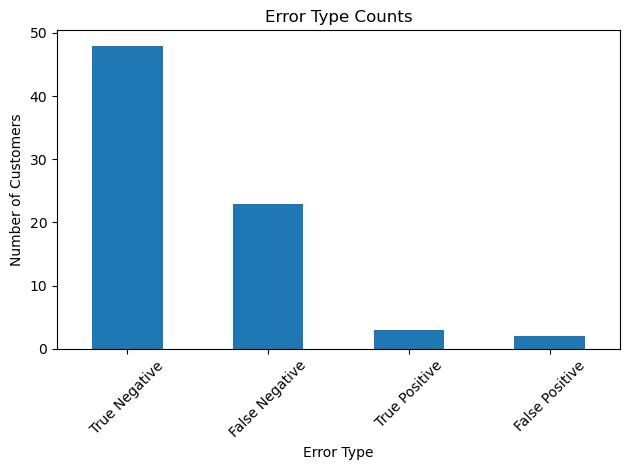

In [26]:
# Visualize the error type counts
error_counts.plot(x="Error Type", y="Count", kind="bar", legend=False)
plt.title("Error Type Counts")
plt.xlabel("Error Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Show only the wrong predictions
wrong_predictions = error_analysis[error_analysis["Correct Prediction"] == False]
wrong_predictions.head(10)

,Customer ID,Actual Churn,Predicted Churn,Correct Prediction,Error Type
2,DS0327,1,0,False,False Negative
3,DS0254,1,0,False,False Negative
6,DS0005,1,0,False,False Negative
9,DS0036,1,0,False,False Negative
14,DS0268,1,0,False,False Negative
17,DS0195,0,1,False,False Positive
20,DS0371,1,0,False,False Negative
23,DS0265,1,0,False,False Negative
28,DS0149,1,0,False,False Negative
29,DS0049,1,0,False,False Negative


### Most Common Error Type and Business Impact

- **Most common error type:** **False Negative** (23 customers). The model repeatedly predicted that a customer would stay when the customer actually churned.
- **Business impact:** every false negative is a real customer who left without the company taking any retention action, which means lost recurring revenue. Because false negatives are by far the largest error group (23, compared with only 2 false positives), the main business risk of this model is that it would let most at-risk customers slip through unnoticed. The model is better at confirming loyal customers than at catching customers who are about to leave.

## Task 9: Cross-Validation

Cross-validation trains and tests the model on several different splits of the data, which gives a more reliable picture of performance than a single split and shows whether the model is stable.

In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Create a 5-fold cross-validation strategy that keeps the churn balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation using accuracy
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

# Show the accuracy for each fold
cv_results = pd.DataFrame({
    "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    "Accuracy": cv_scores
})
cv_results.round(4)

,Fold,Accuracy
0,Fold 1,0.6447
1,Fold 2,0.5921
2,Fold 3,0.7105
3,Fold 4,0.7105
4,Fold 5,0.6053


In [29]:
# Mean and standard deviation of the cross-validation scores
cv_summary = pd.DataFrame({
    "Metric": ["Mean Cross-Validation Accuracy", "Standard Deviation"],
    "Value": [cv_scores.mean(), cv_scores.std()]
})
cv_summary.round(4)

,Metric,Value
0,Mean Cross-Validation Accuracy,0.6526
1,Standard Deviation,0.0503


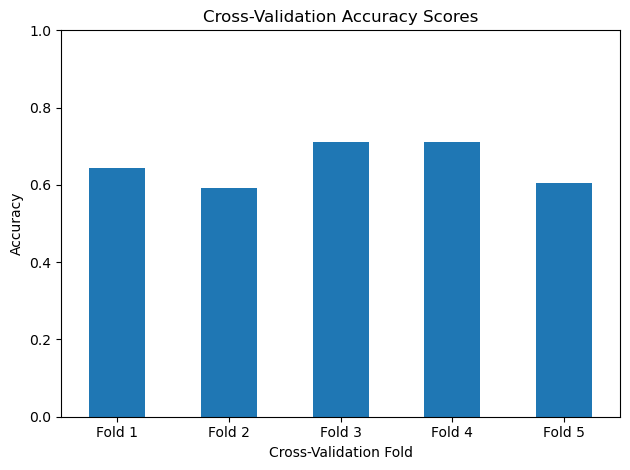

In [30]:
# Visualize the cross-validation accuracy scores
cv_results.plot(x="Fold", y="Accuracy", kind="bar", legend=False)
plt.title("Cross-Validation Accuracy Scores")
plt.xlabel("Cross-Validation Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Is the Model Stable Across Folds?

- The five fold accuracies range from about 0.59 to 0.71, with a mean of about **0.65** and a standard deviation of about **0.05**.
- The spread is moderate: the folds are reasonably close to each other, so the model is **fairly stable** and not wildly dependent on one specific split.
- However, the average accuracy (≈0.65) is close to the "predict everyone stays" baseline of ≈0.66, which confirms that the model has limited real predictive power even though it is stable. A stable but weak model is still weak.

## Task 10: Overfitting and Underfitting Analysis

We compare training accuracy with testing accuracy, and we test different tree depths to see how model complexity affects performance.

In [31]:
# Compare training and testing accuracy for the current model
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, model.predict(X_test))

overfitting_check = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [train_accuracy, test_accuracy]
})
overfitting_check.round(4)

,Dataset,Accuracy
0,Training Data,0.7928
1,Testing Data,0.6711


In [32]:
# Test different tree depths from 1 to 10
depth_results = []
for depth in range(1, 11):
    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    temp_model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, temp_model.predict(X_train))
    test_acc = accuracy_score(y_test, temp_model.predict(X_test))
    depth_results.append([depth, train_acc, test_acc])

depth_results_df = pd.DataFrame(depth_results, columns=["Max Depth", "Training Accuracy", "Testing Accuracy"])
depth_results_df.round(4)

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.6809,0.6316
1,2,0.7171,0.6711
2,3,0.7533,0.6447
3,4,0.7928,0.6711
4,5,0.8421,0.6184
5,6,0.8816,0.6316
6,7,0.9013,0.6053
7,8,0.9441,0.5263
8,9,0.9704,0.5658
9,10,0.9770,0.5526


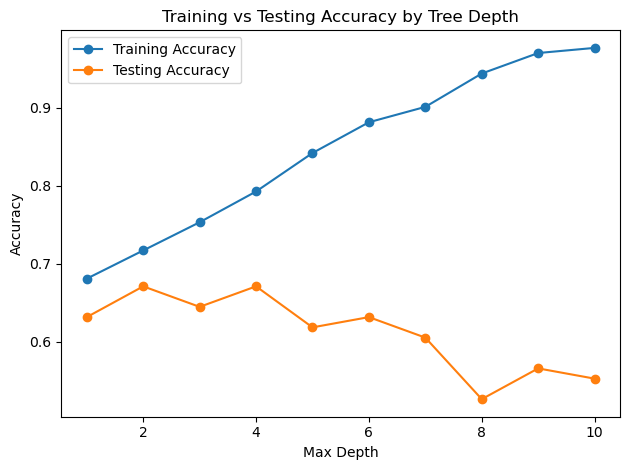

In [33]:
# Visualize training vs testing accuracy across tree depths
plt.plot(depth_results_df["Max Depth"], depth_results_df["Training Accuracy"], marker="o", label="Training Accuracy")
plt.plot(depth_results_df["Max Depth"], depth_results_df["Testing Accuracy"], marker="o", label="Testing Accuracy")
plt.title("Training vs Testing Accuracy by Tree Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Does the Model Overfit or Underfit?

- At `max_depth=4`, training accuracy is about **0.79** and testing accuracy is about **0.67**, a gap of roughly 12 points. This is **mild to moderate overfitting**: the model fits the training data somewhat better than new data.
- As depth increases, the gap grows clearly: at `max_depth=10`, training accuracy climbs to about **0.98** while testing accuracy falls to about **0.55**. This is **strong overfitting**, where the deep tree memorises the training data and fails on new customers.
- Testing accuracy is best at small depths (around depth 2 to 4) and gets worse as the tree grows. There is little sign of underfitting, since even the shallow trees reach the accuracy ceiling for this data.
- **Conclusion:** the model overfits as it gets deeper, so a shallow tree (depth 2 to 4) generalises best. The deeper problem is not depth but weak signal: no depth pushes testing accuracy much above the baseline.

## Task 11: Feature Importance

Feature importance shows which inputs the Decision Tree relied on most when splitting customers into churn and not-churn. This is a simple, global explanation of the model.

In [34]:
# Get feature importance from the trained model
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

feature_importance_df

,Feature,Importance
0,support_tickets,0.208057
1,satisfaction_score,0.120991
2,tenure_months,0.118762
3,days_since_last_purchase,0.103894
4,marketing_emails_opened,0.095787
5,monthly_spend,0.090798
6,income,0.089670
7,website_visits,0.062337
8,membership_level_Silver,0.057027
9,membership_level_Platinum,0.052676


In [35]:
# Select the top 10 most important features
top_features = feature_importance_df.head(10)
top_features

,Feature,Importance
0,support_tickets,0.208057
1,satisfaction_score,0.120991
2,tenure_months,0.118762
3,days_since_last_purchase,0.103894
4,marketing_emails_opened,0.095787
5,monthly_spend,0.090798
6,income,0.089670
7,website_visits,0.062337
8,membership_level_Silver,0.057027
9,membership_level_Platinum,0.052676


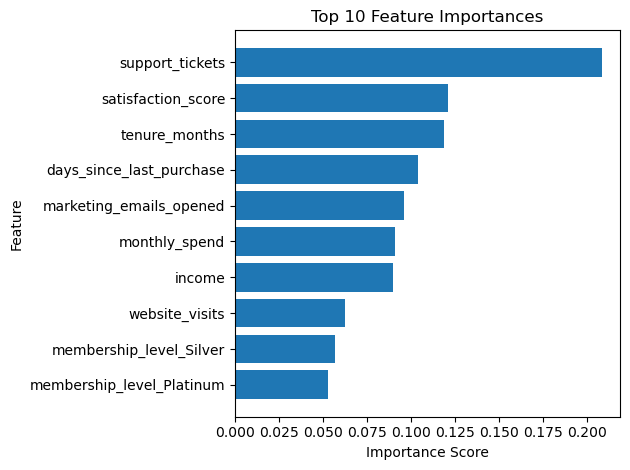

In [36]:
# Visualize the top 10 important features
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Business Meaning of the Important Features

- The most important feature is **support_tickets** (importance ≈0.21), followed by **satisfaction_score** (≈0.12), **tenure_months** (≈0.12), **days_since_last_purchase** (≈0.10), **marketing_emails_opened** (≈0.10), **monthly_spend** (≈0.09), and **income** (≈0.09).
- **Business reading:** churn risk in this model is driven mainly by service and engagement signals. Customers who raise more support tickets, report lower satisfaction, have shorter tenure, and have gone longer since their last purchase are the ones the model leans on to separate churners from stayers. The business should watch these signals closely as early warning signs.
- **Important caution:** feature importance does **not** prove cause and effect. A high importance for support_tickets does not mean support tickets cause churn; it only means this feature was statistically useful for the model's splits. The relationship could run in either direction or be driven by a third factor.

## Task 12: SHAP Explanation

SHAP (SHapley Additive exPlanations) shows how each feature pushes a prediction toward Churn or Not Churn. Unlike feature importance, SHAP can explain both the overall model and a single customer's prediction, including the direction of each effect.

In [38]:
!pip install -q shap

In [39]:
import shap

# Initialize SHAP JavaScript visualization
shap.initjs()

# Create a SHAP explainer for the trained Decision Tree
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)
type(shap_values)

numpy.ndarray

In [40]:
# Different SHAP versions return different formats; select the churn class (class 1)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
    base_value_class1 = explainer.expected_value[1]
else:
    shap_values_class1 = shap_values[:, :, 1]
    base_value_class1 = explainer.expected_value[1]

shap_values_class1.shape

(76, 21)

**Global SHAP summary:** the average impact of each feature on the churn prediction across all test customers.

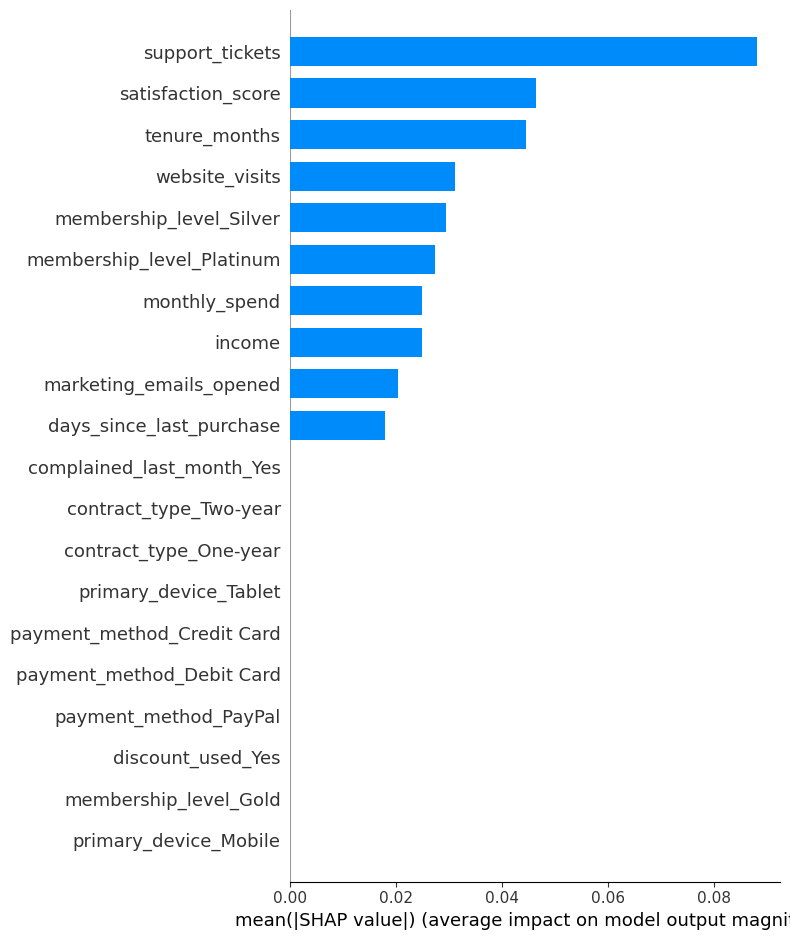

In [41]:
# SHAP summary bar plot (global view)
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

**Local SHAP explanation for one customer** (the first test customer).

In [42]:
# Explain one individual customer
customer_index = 0
customer_data = X_test.iloc[customer_index]
customer_shap_values = shap_values_class1[customer_index]

customer_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": customer_data.values,
    "SHAP Value": customer_shap_values
})
customer_explanation["Absolute SHAP Value"] = customer_explanation["SHAP Value"].abs()
customer_explanation = customer_explanation.sort_values(by="Absolute SHAP Value", ascending=False)
customer_explanation.head(10)

,Feature,Feature Value,SHAP Value,Absolute SHAP Value
16,membership_level_Platinum,True,0.167915,0.167915
7,marketing_emails_opened,3,-0.059882,0.059882
2,tenure_months,10,0.027729,0.027729
1,income,61667.0,-0.020529,0.020529
4,website_visits,33,-0.012837,0.012837
17,membership_level_Silver,False,-0.009484,0.009484
8,days_since_last_purchase,88,-0.008063,0.008063
5,support_tickets,0.0,-0.006154,0.006154
6,satisfaction_score,6.0,-0.004793,0.004793
3,monthly_spend,89.14,-0.000338,0.000338


In [43]:
# Actual and predicted churn for this customer
single_customer_result = pd.DataFrame({
    "Actual Churn": [y_test.iloc[customer_index]],
    "Predicted Churn": [y_pred[customer_index]]
})
single_customer_result

,Actual Churn,Predicted Churn
0,0,0


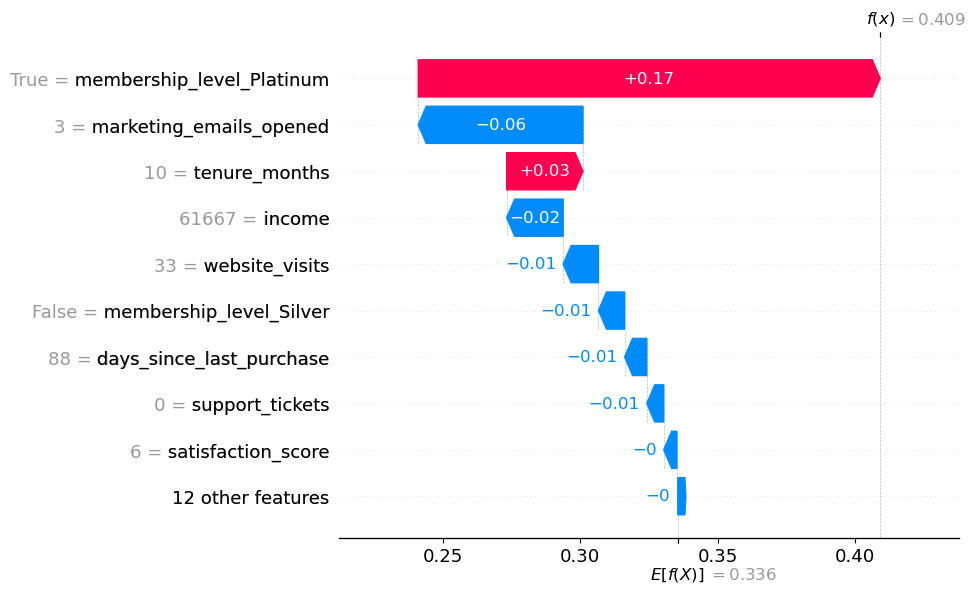

In [44]:
# SHAP waterfall plot for this one customer
single_customer_explanation = shap.Explanation(
    values=customer_shap_values,
    base_values=base_value_class1,
    data=customer_data,
    feature_names=X_test.columns
)
shap.plots.waterfall(single_customer_explanation)

### Interpretation of the SHAP Results

- **Global view:** across all test customers, the features with the strongest average impact on the churn prediction are support_tickets, satisfaction_score, tenure_months, and days_since_last_purchase. This mostly agrees with the feature importance ranking, which increases our confidence in those drivers. The ranking is not identical, because SHAP measures how much each feature shifts predictions across customers, while tree importance measures how much each feature improves the splits.
- **Local view (customer 0):** this customer's actual value is 0 and the model predicted 0, so it is a correct True Negative. The feature pushing hardest toward Churn is `membership_level_Platinum` (positive SHAP ≈+0.17), while features such as marketing_emails_opened, income, and website_visits push toward Not Churn. The negative effects outweigh the positive one, so the model lands on Not Churn.
- **How SHAP helps beyond feature importance:** feature importance only tells us which features matter overall. SHAP also tells us the **direction** of each feature's effect (toward churn or away from it) and lets us explain **one specific customer's** prediction. This makes the model far easier to justify to a business user who asks "why did the model flag this customer".

## Task 13: LIME Explanation

LIME (Local Interpretable Model-agnostic Explanations) explains a single prediction by showing which feature conditions supported the prediction and which worked against it.

In [45]:
!pip install -q lime

In [46]:
from lime.lime_tabular import LimeTabularExplainer

# Prepare data for LIME (numeric arrays)
X_train_lime = X_train.astype(float)
X_test_lime = X_test.astype(float)
feature_names = X_train_lime.columns.tolist()
class_names = ["Not Churn", "Churn"]

# Create the LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True
)

In [47]:
# Explain one customer (the same first test customer)
customer_index = 0
customer_instance = X_test_lime.iloc[customer_index]

lime_explanation = lime_explainer.explain_instance(
    data_row=customer_instance.values,
    predict_fn=model.predict_proba,
    num_features=10
)

# Show the prediction probabilities for this customer
predicted_probabilities = model.predict_proba(X_test_lime.iloc[[customer_index]])[0]
lime_prediction_result = pd.DataFrame({
    "Actual Churn": [y_test.iloc[customer_index]],
    "Predicted Churn": [model.predict(X_test_lime.iloc[[customer_index]])[0]],
    "Probability of Not Churn": [predicted_probabilities[0]],
    "Probability of Churn": [predicted_probabilities[1]]
})
lime_prediction_result.round(4)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,Actual Churn,Predicted Churn,Probability of Not Churn,Probability of Churn
0,0,0,0.5909,0.4091


In [48]:
# LIME explanation as a readable table
lime_explanation_table = pd.DataFrame(
    lime_explanation.as_list(),
    columns=["Feature Condition", "Contribution"]
)
lime_explanation_table

,Feature Condition,Contribution
0,membership_level_Platinum > 0.00,0.133992
1,support_tickets <= 0.00,-0.088910
2,membership_level_Silver <= 0.00,-0.065263
3,marketing_emails_opened <= 4.00,-0.053515
4,tenure_months <= 19.00,0.039315
5,4.00 < satisfaction_score <= 6.00,-0.036786
6,84.39 < monthly_spend <= 105.74,0.025759
7,website_visits > 26.00,-0.024083
8,68.00 < days_since_last_purchase <= 100.25,-0.020705
9,52178.75 < income <= 66950.00,0.014546


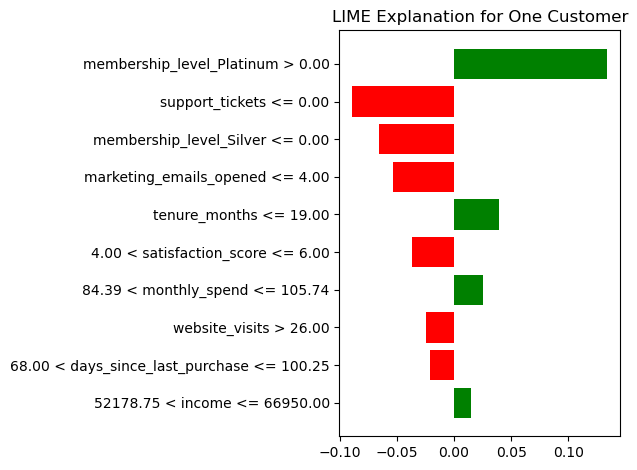

In [49]:
# LIME explanation chart
fig = lime_explanation.as_pyplot_figure()
plt.title("LIME Explanation for One Customer")
plt.tight_layout()
plt.show()

### Interpretation of the LIME Results

- **Prediction probability:** for this customer the model predicts **Not Churn**, with a probability of about 0.59 for Not Churn and about 0.41 for Churn. The actual value is 0, so the prediction is correct, although the 0.41 churn probability shows it is a fairly borderline case.
- **Features supporting Not Churn** (negative contributions): having no support tickets (`support_tickets <= 0`), not being a Silver member, high website visits, and few marketing emails opened all push the prediction toward staying.
- **Features supporting Churn** (positive contributions): Platinum membership and short tenure (`tenure_months <= 19`) push the prediction toward leaving.
- **How LIME helps business users:** LIME translates one prediction into a short, plain list of "reasons for" and "reasons against" in terms of simple feature conditions. A retention manager can read it without understanding the model internals, see why a specific customer was or was not flagged, and decide whether the explanation makes business sense before acting on it.

## Task 14: Fairness and Bias Reflection

We check whether the model behaves differently across customer groups. The group columns (`gender`, `age_group`, `region`) were not used as model inputs, but the model can still behave unevenly because other features may be related to these groups. This is a simple fairness reflection, not a full audit.

In [50]:
# Build a fairness table for the test customers
fairness_data = df.loc[y_test.index, ["customer_id", "gender", "age_group", "region"]].copy()
fairness_data["Actual Churn"] = y_test.values
fairness_data["Predicted Churn"] = y_pred
fairness_data["Correct Prediction"] = fairness_data["Actual Churn"] == fairness_data["Predicted Churn"]
fairness_data.head(10)

,customer_id,gender,age_group,region,Actual Churn,Predicted Churn,Correct Prediction
236,DS0237,Male,36-50,South,0,0,True
314,DS0315,Female,36-50,East,0,0,True
326,DS0327,Male,36-50,East,1,0,False
253,DS0254,Female,36-50,South,1,0,False
261,DS0262,Male,18-25,North,0,0,True
327,DS0328,Male,18-25,West,0,0,True
4,DS0005,Female,26-35,East,1,0,False
124,DS0125,Female,36-50,North,0,0,True
356,DS0357,Female,18-25,North,0,0,True
35,DS0036,Non-binary,18-25,South,1,0,False


In [51]:
# Function that summarizes model behaviour by a group column
def fairness_summary(group_column):
    summary = fairness_data.groupby(group_column).agg(
        Number_of_Customers=("customer_id", "count"),
        Actual_Positive_Rate=("Actual Churn", "mean"),
        Predicted_Positive_Rate=("Predicted Churn", "mean"),
        Accuracy=("Correct Prediction", "mean")
    ).reset_index()
    return summary

**Fairness by gender.**

In [52]:
gender_fairness = fairness_summary("gender")
gender_fairness.round(3)

,gender,Number_of_Customers,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,Female,36,0.361,0.111,0.639
1,Male,38,0.316,0.026,0.711
2,Non-binary,2,0.500,0.000,0.500


**Fairness by region.**

In [53]:
region_fairness = fairness_summary("region")
region_fairness.round(3)

,region,Number_of_Customers,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,East,20,0.250,0.050,0.800
1,North,20,0.400,0.050,0.650
2,South,24,0.417,0.042,0.625
3,West,12,0.250,0.167,0.583


**Fairness by age group.**

In [54]:
age_group_fairness = fairness_summary("age_group")
age_group_fairness.round(3)

,age_group,Number_of_Customers,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,18-25,12,0.417,0.083,0.667
1,26-35,23,0.348,0.043,0.696
2,36-50,31,0.419,0.097,0.548
3,51+,10,0.000,0.000,1.000


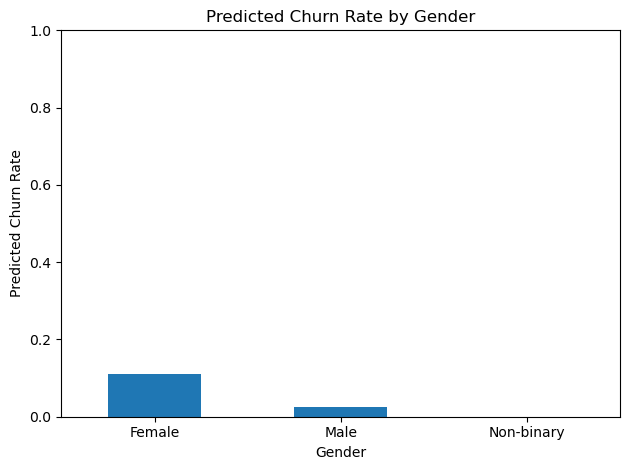

In [55]:
# Visualization: predicted churn rate by gender
gender_fairness.plot(x="gender", y="Predicted_Positive_Rate", kind="bar", legend=False)
plt.title("Predicted Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Predicted Churn Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

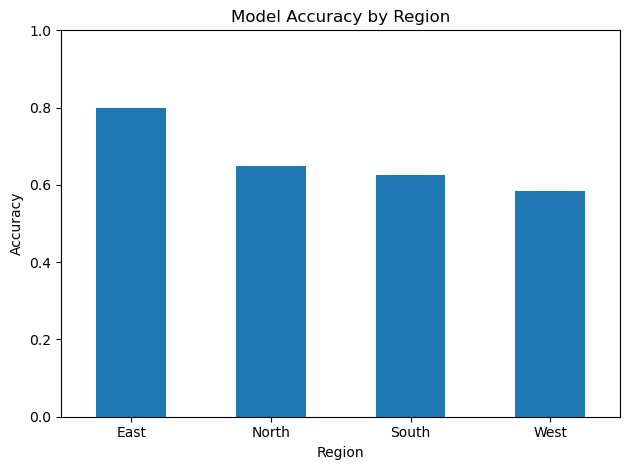

In [56]:
# Visualization: accuracy by region
region_fairness.plot(x="region", y="Accuracy", kind="bar", legend=False)
plt.title("Model Accuracy by Region")
plt.xlabel("Region")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Fairness and Bias Reflection

- **The model under-predicts churn for every group.** In all groups the predicted churn rate is far below the actual churn rate (for example, females churn at ≈36% but are predicted to churn at ≈11%; males churn at ≈32% but are predicted at ≈3%). This is the low-recall problem from Task 6 showing up across the whole population.
- **Accuracy is not equal across groups.** By gender, accuracy is higher for males (≈0.71) than females (≈0.64). By region, it ranges from ≈0.58 (West) to ≈0.80 (East). By age group it ranges widely, but some groups are very small.
- **Small groups are unreliable.** The Non-binary gender group (2 test customers) and the 51+ age group (10 test customers) are too small to draw firm conclusions, so their numbers should be read with caution.
- **Does this create unfair business decisions:** potentially yes. Because the model flags churn slightly more often for some groups (for example, females and West-region customers) than others, those groups could receive more retention offers while equally at-risk customers in other groups are overlooked. Even though gender and region were not model inputs, related behavioural features can carry that information indirectly. The differences here are small and partly driven by tiny group sizes, but they are enough to require human review before the model is used for targeting.

## Task 15: Final Business Interpretation

In [57]:
# Build a final business summary table
final_train_acc = accuracy_score(y_train, model.predict(X_train))
final_test_acc = accuracy_score(y_test, y_pred)

business_summary = pd.DataFrame({
    "Result": [
        "Training Accuracy", "Testing Accuracy", "Precision", "Recall", "F1-Score",
        "True Negative", "False Positive", "False Negative", "True Positive"
    ],
    "Value": [
        round(final_train_acc, 4), round(final_test_acc, 4), round(precision, 4),
        round(recall, 4), round(f1, 4), tn, fp, fn, tp
    ],
    "Business Meaning": [
        "How well the model learned from old data",
        "How well the model works on new customers",
        "Of predicted churners, how many actually churned",
        "Of actual churners, how many the model caught",
        "Balance between precision and recall",
        "Customers correctly predicted as not churn",
        "Customers wrongly predicted as churn",
        "Churners the model missed",
        "Churners the model correctly identified"
    ]
})
business_summary

,Result,Value,Business Meaning
0,Training Accuracy,0.7928,How well the model learned from old data
1,Testing Accuracy,0.6711,How well the model works on new customers
2,Precision,0.6000,"Of predicted churners, how many actually churned"
3,Recall,0.1154,"Of actual churners, how many the model caught"
4,F1-Score,0.1935,Balance between precision and recall
5,True Negative,48.0000,Customers correctly predicted as not churn
6,False Positive,2.0000,Customers wrongly predicted as churn
7,False Negative,23.0000,Churners the model missed
8,True Positive,3.0000,Churners the model correctly identified


### Final Business Interpretation

- **What the model predicts:** whether a digital subscription customer will churn (leave) or stay, using behavioural, subscription, and engagement features.
- **Overall performance:** weak. Testing accuracy is about 0.67, but that is barely above the ≈0.66 baseline of predicting that everyone stays, and cross-validation confirms a stable but low average accuracy of ≈0.65.
- **Most important evaluation metric:** Recall, because this is a retention problem. The model's recall is only ≈0.12, so it catches very few real churners.
- **Main error type:** False Negatives (23 of them). The model repeatedly predicts that churning customers will stay.
- **Business impact of errors:** false negatives mean at-risk customers are missed and leave without any retention action, causing lost recurring revenue. False positives (only 2) cause minor wasted retention spend. The error mix is heavily weighted toward the more expensive mistake for a subscription business.
- **Overfitting evidence:** the training accuracy (≈0.79) exceeds testing accuracy (≈0.67) at depth 4, and the gap grows sharply at higher depths (depth 10: train ≈0.98, test ≈0.55). The model overfits as it deepens.
- **Most important features:** support_tickets, satisfaction_score, tenure_months, and days_since_last_purchase. Service quality and engagement signals dominate.
- **SHAP and LIME insight:** both explainers confirm that service and engagement features drive predictions and let us explain individual cases. For the sample customer, low support-ticket activity and engagement pushed the prediction toward Not Churn, and the prediction was a correct True Negative.
- **Fairness and bias concern:** the model under-predicts churn for all groups and has uneven accuracy across gender, region, and age group (some of which have very small samples). Used as-is for targeting, it could give some groups less retention attention than they need.
- **Final recommendation:** **This model is not ready for real business use.** It is suitable only as an **early prototype**. Its recall is far too low to support retention decisions. Before any real use it needs improvement: gather more churn examples, engineer stronger features, address the class imbalance (for example class weights or resampling), tune the decision threshold to raise recall, and compare other models such as Logistic Regression, Random Forest, or Gradient Boosting. It should support human judgment, not replace it.